<a href="https://colab.research.google.com/github/mpar20-cpu/Projekt-Wine-Quality/blob/main/Projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data loading and exploration

In [ ]:
import pandas as pd
import numpy as np

wine = pd.read_csv("WineQT.csv")
wine = wine.drop("Id", axis=1)
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [ ]:
wine["quality"].value_counts()

,count
quality,
5,483
6,462
7,143
4,33
8,16
3,6


In [ ]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


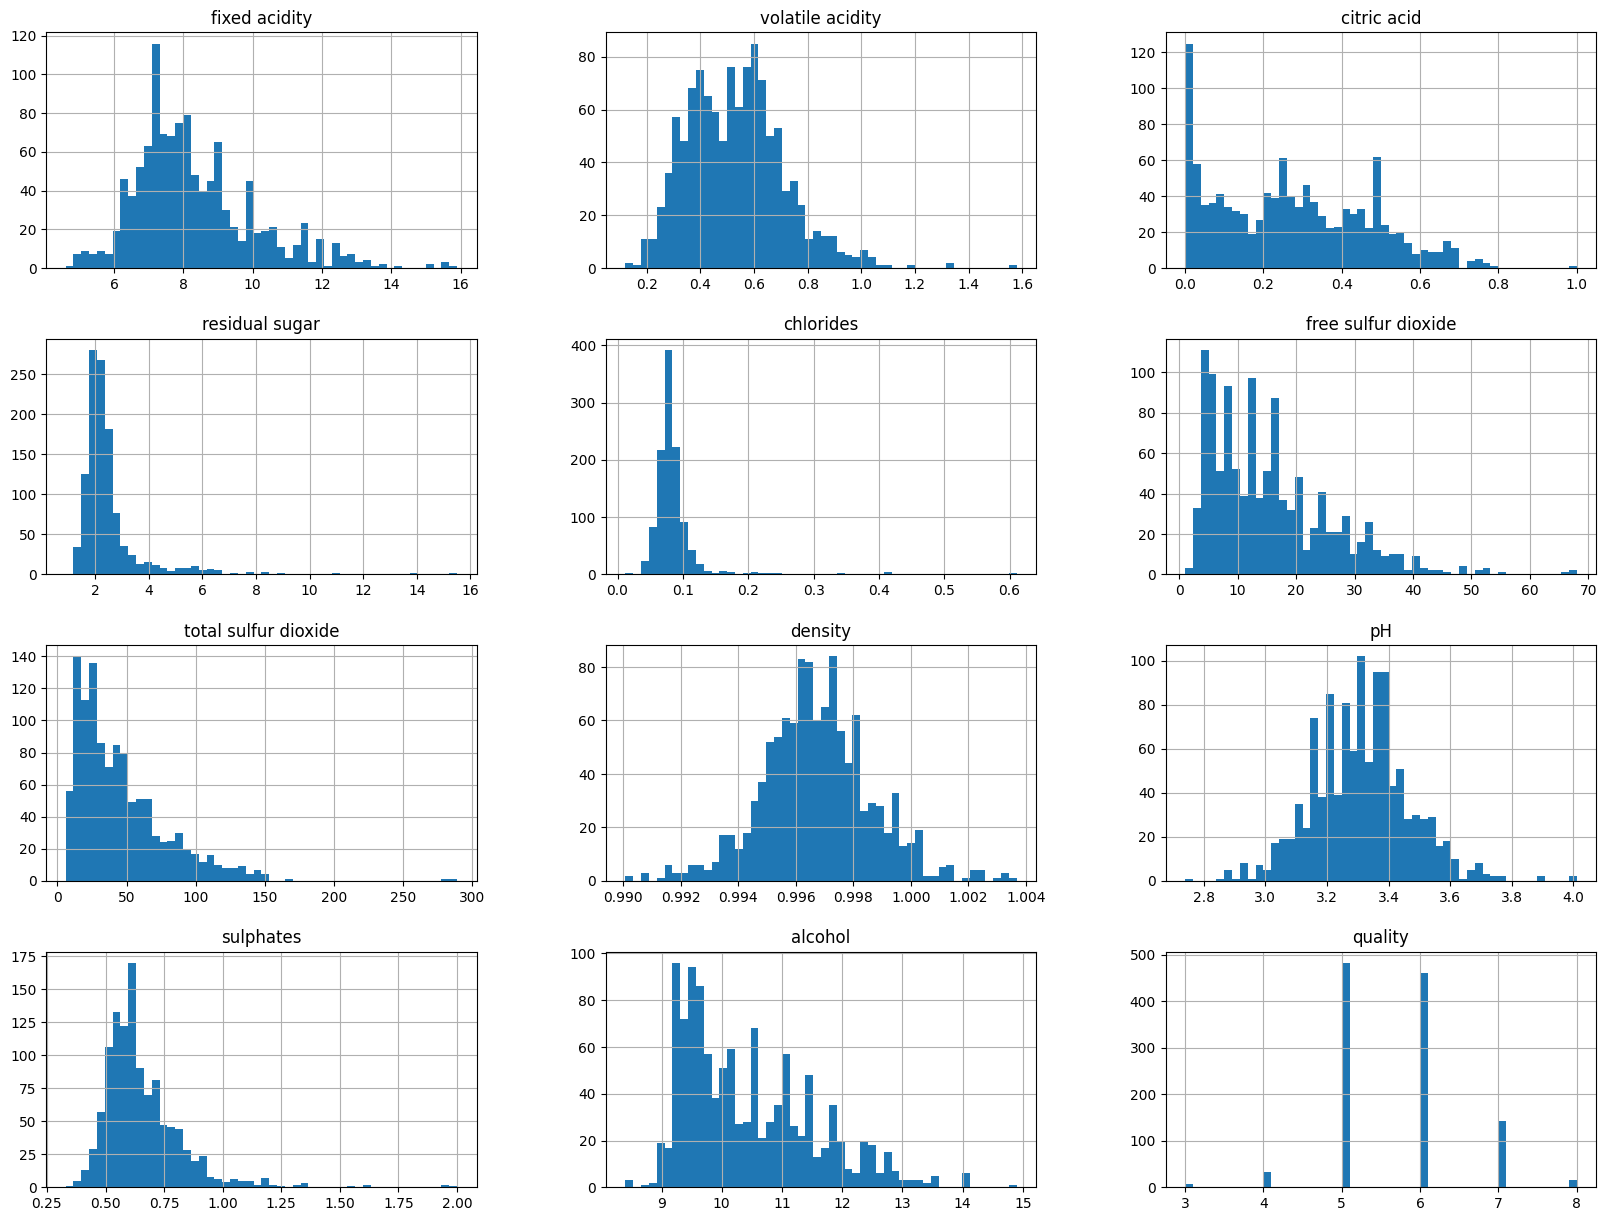

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
wine.hist(bins=50, figsize=(20,15))
plt.show()

## Train - test slip

In [ ]:
from sklearn.model_selection import train_test_split
X = wine.drop("quality", axis=1)
y = wine["quality"].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
wine["quality"].value_counts() / len(wine)

,count
quality,
5,0.422572
6,0.404199
7,0.125109
4,0.028871
8,0.013998
3,0.005249


## Visualisations and correlations

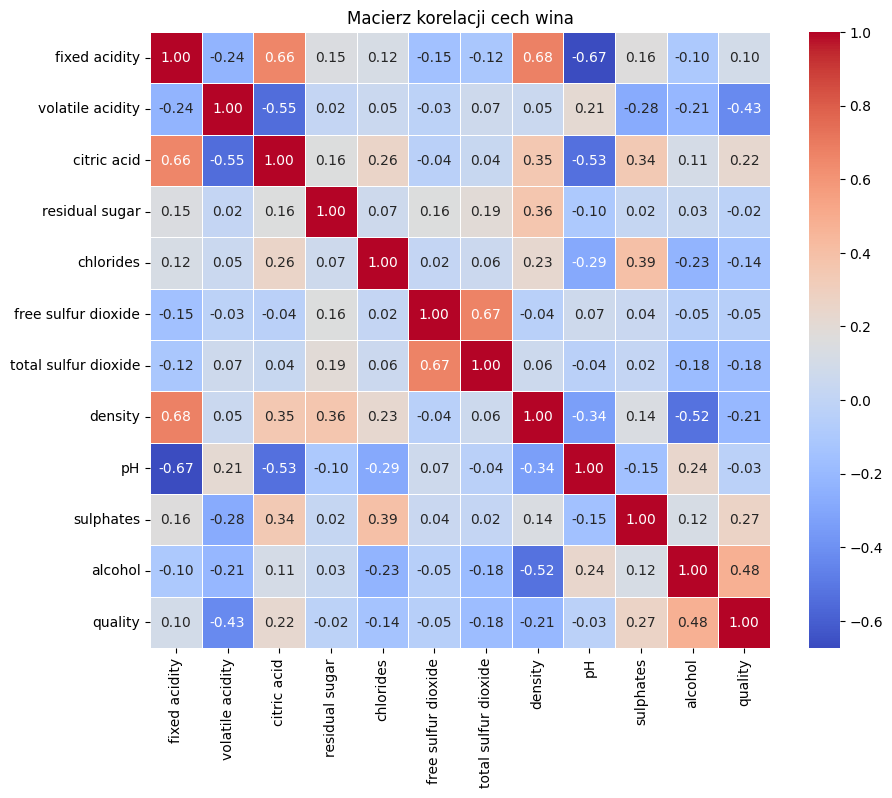

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

wine_exploration = X_train.copy()
wine_exploration["quality"] = y_train

corr_matrix = wine_exploration.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Macierz korelacji cech wina")
plt.show()


In [ ]:
wine_attributes = ["quality", "alcohol", "volatile acidity", "sulphates", "citric acid"]
wine_train = X_train.copy()
wine_train['quality'] = y_train

wine_train[wine_attributes].corr()

,quality,alcohol,volatile acidity,sulphates,citric acid
quality,1.000000,0.481643,-0.426460,0.265516,0.224386
alcohol,0.481643,1.000000,-0.211609,0.120295,0.108099
volatile acidity,-0.426460,-0.211609,1.000000,-0.277761,-0.549262
sulphates,0.265516,0.120295,-0.277761,1.000000,0.341180
citric acid,0.224386,0.108099,-0.549262,0.341180,1.000000


Zawartość alkoholu ma najsilniejszy, dodatni wpływ na jakość wina (0.48).
Negatywny wpływ ma lotna kwasowość (volatile acidity).

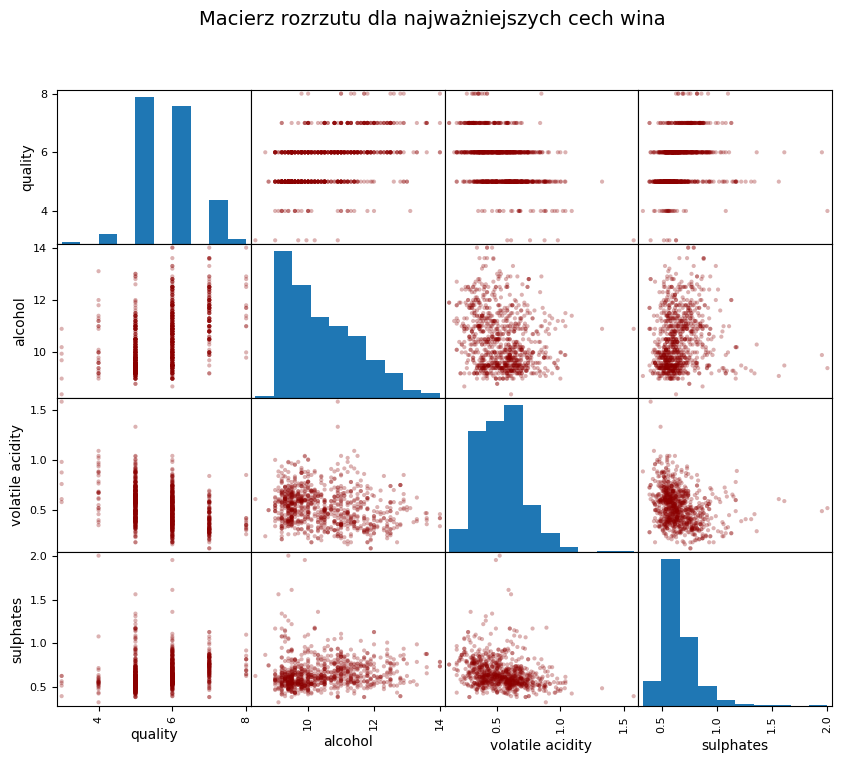

In [ ]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

wine_attributes = ["quality", "alcohol", "volatile acidity", "sulphates"]

scatter_matrix(wine_exploration[wine_attributes], figsize=(10, 8), color="darkred", alpha=0.3)

plt.suptitle("Macierz rozrzutu dla najważniejszych cech wina", fontsize=14)
plt.show()


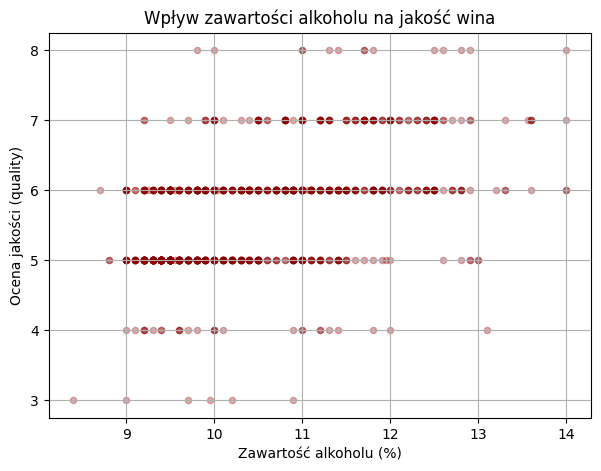

In [ ]:
wine_exploration.plot(kind="scatter", x="alcohol", y="quality", alpha=0.3, figsize=(7, 5), color="darkred")
plt.title("Wpływ zawartości alkoholu na jakość wina")
plt.xlabel("Zawartość alkoholu (%)")
plt.ylabel("Ocena jakości (quality)")
plt.grid(True)
plt.show()


In [ ]:
wine_corr = wine_exploration.corr()

print("Wpływ poszczególnych cech na jakość wina (od najsilniejszego do najsłabszego):")
print(wine_corr["quality"].sort_values(ascending=False))


Wpływ poszczególnych cech na jakość wina (od najsilniejszego do najsłabszego):
quality                 1.000000
alcohol                 0.481643
sulphates               0.265516
citric acid             0.224386
fixed acidity           0.095843
residual sugar         -0.021126
pH                     -0.027518
free sulfur dioxide    -0.051602
chlorides              -0.138725
total sulfur dioxide   -0.177014
density                -0.208828
volatile acidity       -0.426460
Name: quality, dtype: float64


# Data cleaning - pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_attribs = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
               'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
               'pH', 'sulphates', 'alcohol']

num_pipeline = Pipeline([
    ('std_scaler', StandardScaler()),
])

In [ ]:
wine_prepared = num_pipeline.fit_transform(X_train)
wine_prepared

array([[ 0.1426802 , -1.40273053,  1.5096933 , ..., -0.09314751,
         0.56821234,  0.05661327],
       [ 0.96843134, -1.17920341,  1.5096933 , ..., -1.07474038,
         0.4477703 ,  0.89445566],
       [ 0.3786091 , -1.23508519,  0.4833938 , ...,  0.56124774,
         0.20688622,  1.26683005],
       ...,
       [-0.50612428, -1.01155806,  0.32944888, ...,  0.29948964,
        -0.33510296,  1.35992365],
       [-0.21121315,  0.21784112,  0.22681893, ..., -0.15858703,
         0.20688622, -0.87432272],
       [-0.44714205, -0.06156778,  0.6886537 , ..., -0.35490561,
        -0.09421888,  1.26683005]])

In [ ]:
wine_prepared.shape

(914, 11)

In [ ]:
pd.DataFrame(wine_prepared)

,0,1,2,3,4,5,6,7,8,9,10
0,0.142680,-1.402731,1.509693,-0.551024,0.116516,1.885598,1.791223,0.113558,-0.093148,0.568212,0.056613
1,0.968431,-1.179203,1.509693,-0.397768,-0.284239,-1.241882,-1.185720,-0.701767,-1.074740,0.447770,0.894456
2,0.378609,-1.235085,0.483394,0.061998,-0.642809,-0.557745,-0.214297,-0.555427,0.561248,0.206886,1.266830
3,-0.977982,1.950176,-1.158685,-0.244513,-0.431885,-0.362278,-0.809685,-0.168670,1.411962,-0.575987,-0.501948
4,-0.388160,-0.620386,-0.081071,1.058159,0.369624,1.201462,1.383852,0.604843,-1.074740,-0.515766,-1.246697
...,...,...,...,...,...,...,...,...,...,...,...
909,-0.919000,2.844285,-0.953425,-0.167885,-0.410793,0.321858,-0.433650,-0.105953,1.346522,-0.515766,0.522081
910,-0.152231,-0.788031,0.175504,-0.474396,-0.263147,1.592397,1.195834,0.254672,0.495808,-0.274882,-1.339791
911,-0.506124,-1.011558,0.329449,-0.091257,-0.389701,-0.655479,-0.621668,-1.036259,0.299490,-0.335103,1.359924
912,-0.211213,0.217841,0.226819,-0.397768,-0.157685,-0.557745,1.039153,0.045614,-0.158587,0.206886,-0.874323


# Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(wine_prepared, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error

wine_predictions = lin_reg.predict(wine_prepared)
lin_mse = mean_squared_error(y_train, wine_predictions)
lin_rmse = np.sqrt(lin_mse)

print("Średni błąd (RMSE) Regresji Liniowej na zbiorze treningowym wynosi:")
lin_rmse


Średni błąd (RMSE) Regresji Liniowej na zbiorze treningowym wynosi:


np.float64(0.6442910255023866)

In [ ]:
def display_scores(scores):
    print("Wyniki (błędy RMSE):", scores)
    print("Średni błąd (Mean):", scores.mean())
    print("Odchylenie standardowe (Std):", scores.std())

In [ ]:
from sklearn.model_selection import cross_val_score

lin_scores = cross_val_score(lin_reg, wine_prepared, y_train, scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Wyniki (błędy RMSE): [0.59038965 0.7043892  0.76070752 0.56943805 0.71908566 0.66552423
 0.63403397 0.59297419 0.66088097 0.60852618]
Średni błąd (Mean): 0.6505949622329649
Odchylenie standardowe (Std): 0.059677115719791625


# Decision Tree Regressor Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(wine_prepared, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
wine_predictions_tree = tree_reg.predict(wine_prepared)

tree_mse = mean_squared_error(y_train, wine_predictions_tree)
tree_rmse = np.sqrt(tree_mse)

print("Średni błąd (RMSE) Drzewa Decyzyjnego na zbiorze treningowym wynosi:")
tree_rmse

Średni błąd (RMSE) Drzewa Decyzyjnego na zbiorze treningowym wynosi:


np.float64(0.0)

In [ ]:
tree_scores = cross_val_score(tree_reg, wine_prepared, y_train, scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-tree_scores)
display_scores(tree_rmse_scores)

Wyniki (błędy RMSE): [0.81427482 0.90889326 0.82092207 0.80757285 0.85163063 0.77742884
 0.87705802 0.78446454 0.74124932 0.9078413 ]
Średni błąd (Mean): 0.8291335643495336
Odchylenie standardowe (Std): 0.05338989034153801


# Random Forest Regressor Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(wine_prepared, y_train)

wine_predictions_forest = forest_reg.predict(wine_prepared)
forest_mse = mean_squared_error(y_train, wine_predictions_forest)
forest_rmse = np.sqrt(forest_mse)

print("Wstępny błąd (RMSE) Lasu Losowego na zbiorze treningowym wynosi:")
forest_rmse

Wstępny błąd (RMSE) Lasu Losowego na zbiorze treningowym wynosi:


np.float64(0.22836566132744865)

In [ ]:
forest_scores = cross_val_score(forest_reg, wine_prepared, y_train, scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)

display_scores(forest_rmse_scores)

Wyniki (błędy RMSE): [0.60944023 0.65286659 0.71210725 0.54004328 0.66693575 0.58304242
 0.59656894 0.57726429 0.59485338 0.60255226]
Średni błąd (Mean): 0.6135674402080453
Odchylenie standardowe (Std): 0.047471807664644525


In [ ]:
mean_quality = y_train.mean()

print("Średnia ocena jakości wina wynosi:")
mean_quality

Średnia ocena jakości wina wynosi:


np.float64(5.656455142231947)

# Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]

forest_reg = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

grid_search.fit(wine_prepared, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [ ]:
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [ ]:
final_model = grid_search.best_estimator_
final_model

RandomForestRegressor(max_features=8, n_estimators=30, random_state=42)

# Ocena na zbiorze testowym

In [ ]:
X_test_prepared = num_pipeline.transform(X_test)

In [ ]:
test_pred = final_model.predict(X_test_prepared)

print("Przykładowe prognozy jakości wina:")
test_pred[:5]

Przykładowe prognozy jakości wina:


array([5.16666667, 5.73333333, 5.56666667, 5.13333333, 6.33333333])

In [ ]:
test_mse = mean_squared_error(y_test, test_pred)

final_rmse = np.sqrt(test_mse)
final_rmse

np.float64(0.552911222521569)

# Randomized search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
        'n_estimators': randint(low=1, high=100),
        'max_features': randint(low=1, high=8),
    }

forest_reg = RandomForestRegressor(random_state=42)

rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=20, cv=5, scoring='neg_mean_squared_error', random_state=42)

rnd_search.fit(wine_prepared, y_train)
rnd_search.best_params_

{'max_features': 3, 'n_estimators': 88}

In [ ]:
rnd_best_model = rnd_search.best_estimator_
rnd_test_pred = rnd_best_model.predict(X_test_prepared)

rnd_test_mse = mean_squared_error(y_test, rnd_test_pred)
rnd_test_rmse = np.sqrt(rnd_test_mse)

rnd_test_rmse

np.float64(0.530172695187828)